In [1]:

%load_ext autoreload
%autoreload 2

In [2]:
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns

from pandas.api.types import CategoricalDtype
from statsmodels.stats.multitest import multipletests
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_validate, train_test_split,
)

from projeto import visualizer as vizu
from projeto import testes
from pyprojroot import here

ALVO    = "Sleep_Quality"
CLASSES = ["Poor", "Fair", "Good", "Excellent"]
ORDENS = {
    "Sleep_Quality": CLASSES,
    "Stress_Level": ["Low", "Medium", "High"],
    "Health_Issues": ["No Issues", "Mild", "Moderate", "Severe"],
}

# COFFEE & SLEEP — Fatores associados à qualidade do sono
## Análise Exploratória, Testes Estatísticos e Modelagem
Metodologia: CRISP-DM

1. Definição do problema
2. Compreensão dos dados
3. Preparação dos dados
4. Modelagem
5. Avaliação
6. Conclusão

# **1. DEFINIR O PROBLEMA DE NEGÓCIO**

- **Pergunta:** quais fatores de estilo de vida estão associados à qualidade do sono, e é possível prevê-la a partir deles?

- **Alvo:** Sleep_Quality (Poor, Fair, Good, Excellent).

- O dataset contém 10.000 registros sintéticos relacionando consumo de café, hábitos de sono e indicadores de saúde em 20 países.

Fonte: https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset

# **2. COMPREENSÃO DOS DADOS**

- O dataset foi coletado em: https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset

- O conjunto de dados GlobalCoffeeHealth contém 10.000 registros sintéticos que refletem padrões reais de consumo de café, comportamento do sono e indicadores de saúde em 20 países. Ele abrange dados demográficos, ingestão diária de café, níveis de cafeína, duração e qualidade do sono, IMC, frequência cardíaca, estresse, atividade física, problemas de saúde, ocupação, tabagismo e consumo de álcool.

- O conjunto de dados captura correlações realistas observadas em pesquisas — como o impacto da cafeína no sono, no estresse e na saúde —, tornando-o ideal para análises estatísticas, modelagem preditiva e estudos sobre estilo de vida ou bem-estar.

## **2.1 COLETA E INTEGRAÇÃO INICIAL DE DADOS**

1. Leitura do CSV sem nenhuma transformação (base bruta, usada na checagem de qualidade da 2.2).
2. Health_Issues: a célula vazia significa "sem problema de saúde" e vira a categoria **No Issues** (justificativa na 2.2).
3. Conversão das variáveis ordinais (Sleep_Quality, Stress_Level, Health_Issues) para categóricas ordenadas.

In [3]:
bruto = pd.read_csv(here("data/raw/synthetic_coffee_health_10000(in).csv"))

df = bruto.copy()
df["Health_Issues"] = df["Health_Issues"].fillna("No Issues")
for coluna, ordem in ORDENS.items():
    df[coluna] = df[coluna].astype(CategoricalDtype(ordem, ordered=True))

# Uma categoria com grafia fora da ordem esperada viraria NaN sem aviso
assert df[list(ORDENS)].isna().sum().sum() == 0, "Categoria fora da ordem esperada virou NaN"

variaveis_numericas = [
    col for col in df.select_dtypes(include="number").columns
    if df[col].nunique() > 2 and col != "ID"
]
variaveis_binarias = [col for col in df.columns if df[col].nunique() == 2]

variaveis_textuais = [
    col for col in df.select_dtypes(include=["object", "category"]).columns
    if df[col].nunique() > 2
]
variaveis_categoricas = variaveis_textuais + variaveis_binarias

print("Numéricas:  ", variaveis_numericas)
print("Categóricas:", variaveis_categoricas)

Numéricas:   ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours']
Categóricas: ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Health_Issues', 'Occupation', 'Smoking', 'Alcohol_Consumption']


## **2.2 ANÁLISE DESCRITIVA**


- **ID**   Integer	Identificador único de cada registro (1–10000).
- **Age**	Integer	Idade do participante (18 a 80 anos).
- **Gender**	Categorical	Gênero: Male, Female ou Other.
- **Country**	Categorical	País de residência (20 países representados).
- **Coffee_Intake**	Float	Consumo diário de café em xícaras (0 a 10).
- **Caffeine_mg**	Float	Estimativa de cafeína ingerida por dia em mg (1 xícara ≈ 95 mg).
- **Sleep_Hours**	Float	Média de horas de sono por noite (3 a 10 horas).
- **Sleep_Quality**	Categorical	Qualidade do sono: Poor, Fair, Good ou Excellent.
- **BMI**	Float	Índice de Massa Corporal (15 a 40).
- **Heart_Rate**	Integer	Frequência cardíaca em repouso (50 a 110 bpm).
- **Stress_Level**	Categorical	Nível de estresse: Low, Medium ou High.
- **Physical_Activity_Hours**	Float	Tempo de atividade física semanal em horas (0 a 15).
- **Health_Issues**	Categorical	Condições de saúde: No Issues, Mild, Moderate ou Severe. No CSV, No Issues vem como célula vazia (o dicionário original do dataset chama de None).
- **Occupation**	Categorical	Ocupação principal: Office, Healthcare, Student, Service, Other.
- **Smoking**	Boolean	Fumante: 0 = Não, 1 = Sim.
- **Alcohol_Consumption**	Boolean	Consome álcool: 0 = Não, 1 = Sim.

In [4]:
# Checagem feita na base BRUTA, antes de qualquer tratamento
print(f"Formato do dataset: {bruto.shape[0]} linhas e {bruto.shape[1]} colunas")
print(f"Registros duplicados: {bruto.duplicated().sum()}\n")

nulos = bruto.isna().sum()
nulos = nulos[nulos > 0]
if nulos.empty:
    print("- O dataset não possui valores nulos.")
else:
    print("- Valores nulos na base bruta:")
    display(pd.DataFrame({"Nulos": nulos, "%": (nulos / len(bruto) * 100).round(1)}))

Formato do dataset: 10000 linhas e 16 colunas
Registros duplicados: 0

- Valores nulos na base bruta:


,Nulos,%
Health_Issues,5941,59.4


##### TRATAMENTO DE HEALTH_ISSUES

- Os únicos valores ausentes da base estão em **Health_Issues**: 5.941 células vazias (59,4%).
- O vazio **não é dado faltante**: o dicionário do dataset lista a categoria None (sem problema de saúde), que não aparece no CSV, e o grupo segue um padrão claro com o alvo (0% dos Poor/Fair e ~85% dos Good/Excellent, ver 2.5).
- Por isso ele foi rotulado como **No Issues** em vez de imputado ou descartado. Descartar 59% da coluna eliminaria justamente o grupo mais saudável.

## **2.3 ANÁLISE EXPLORATÓRIA**

#### 2.3.1 VARIÁVEIS NUMÉRICAS

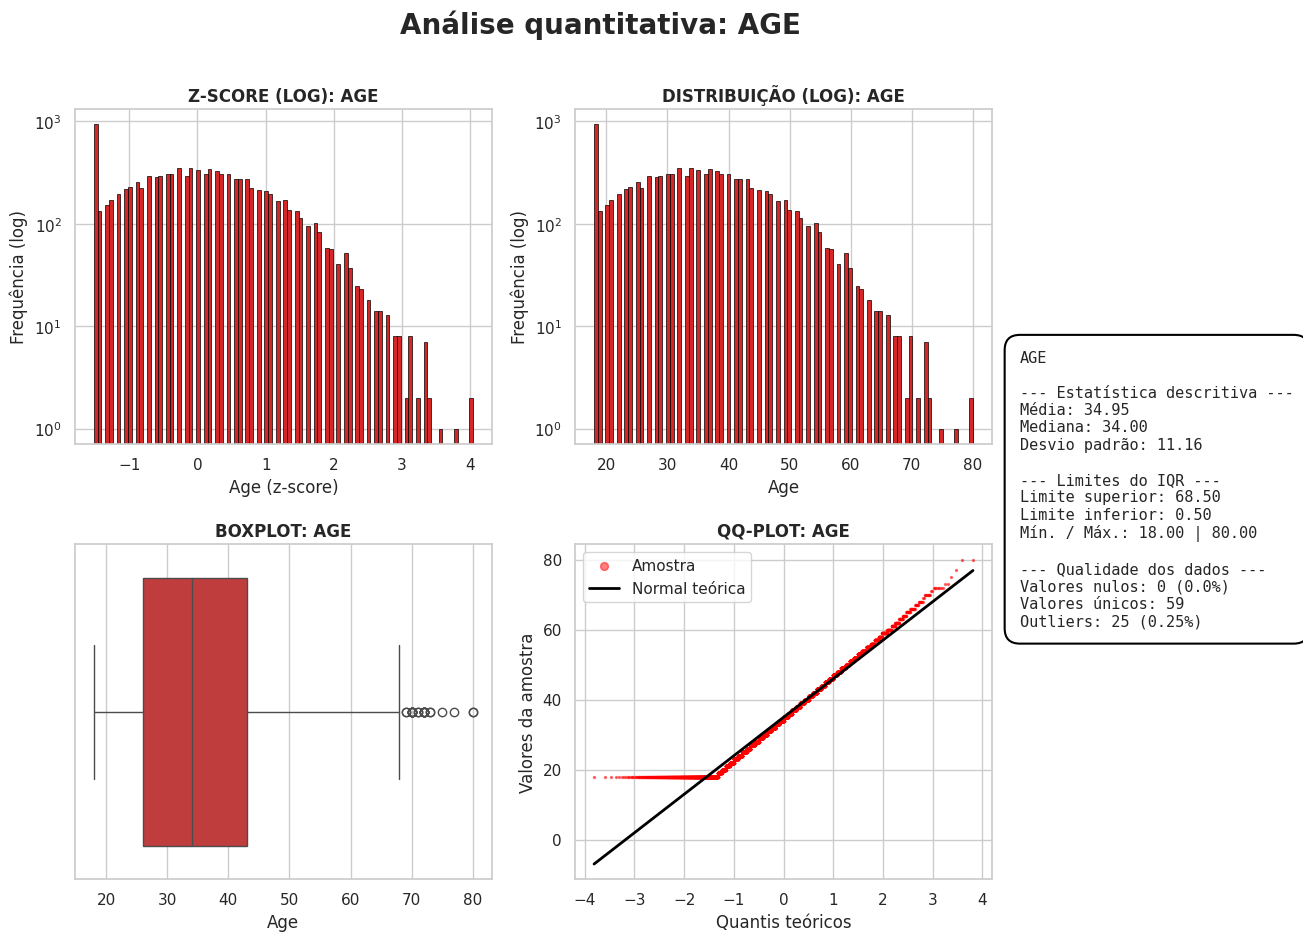

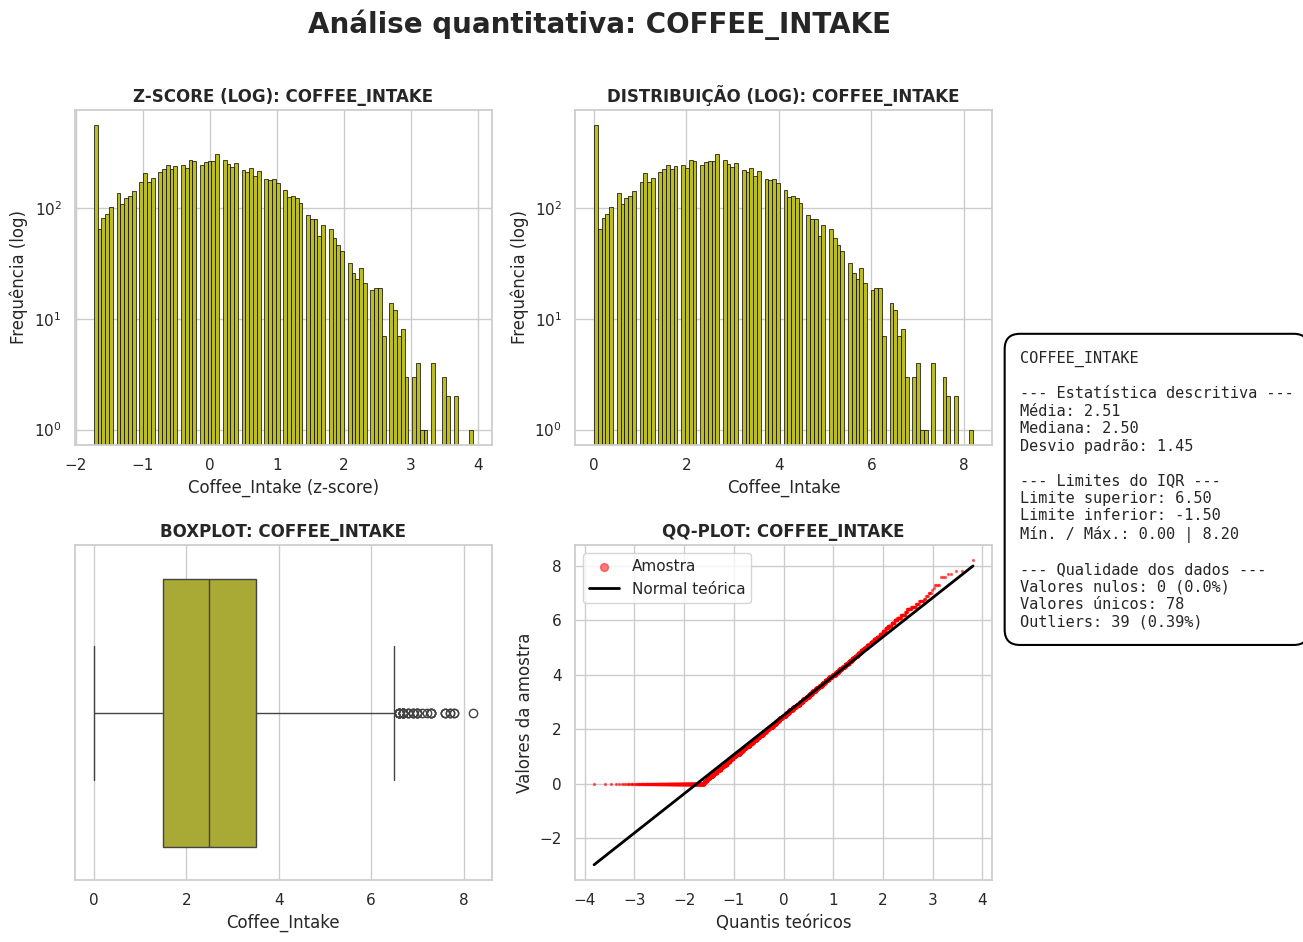

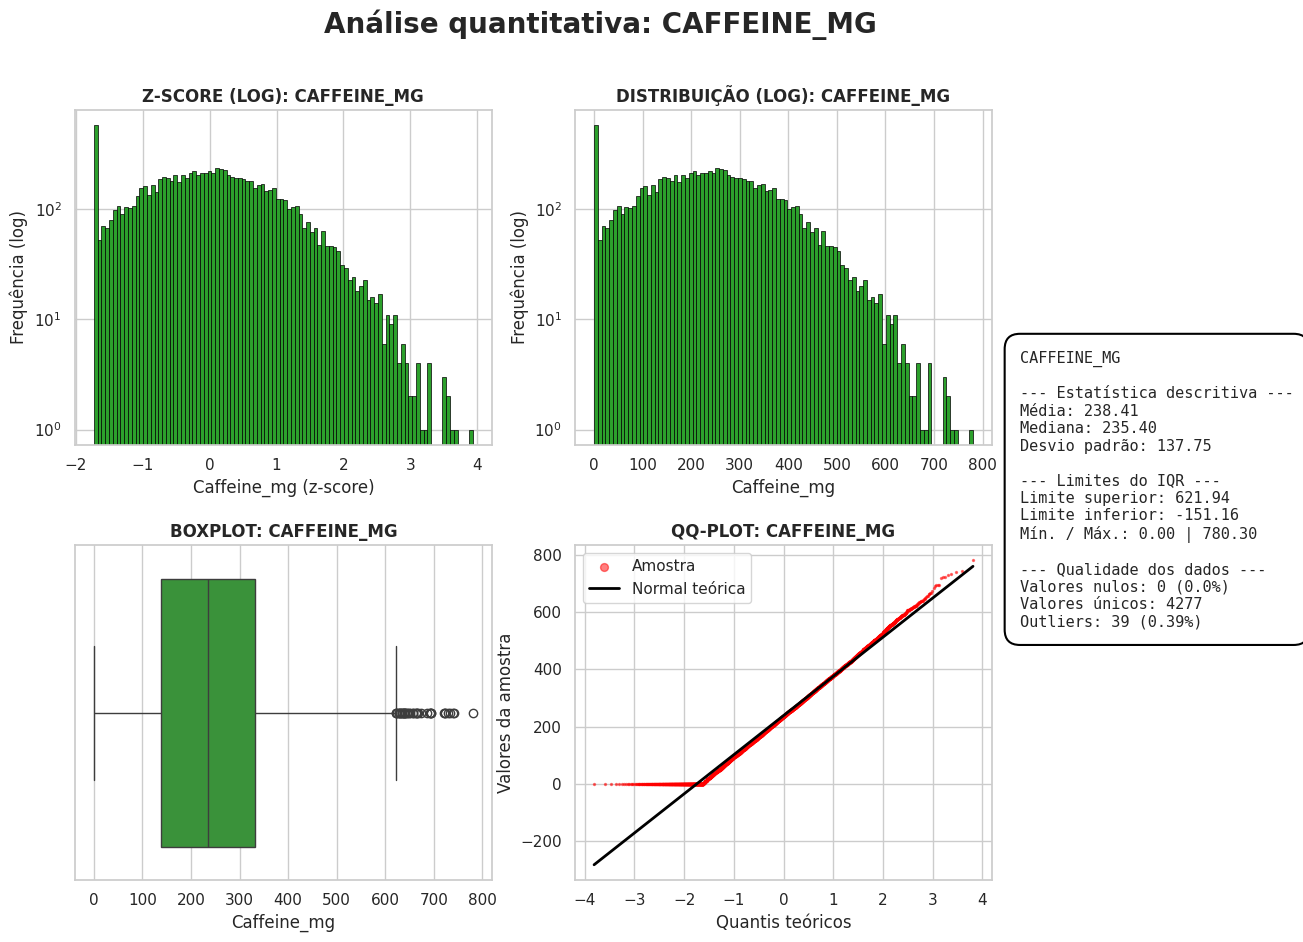

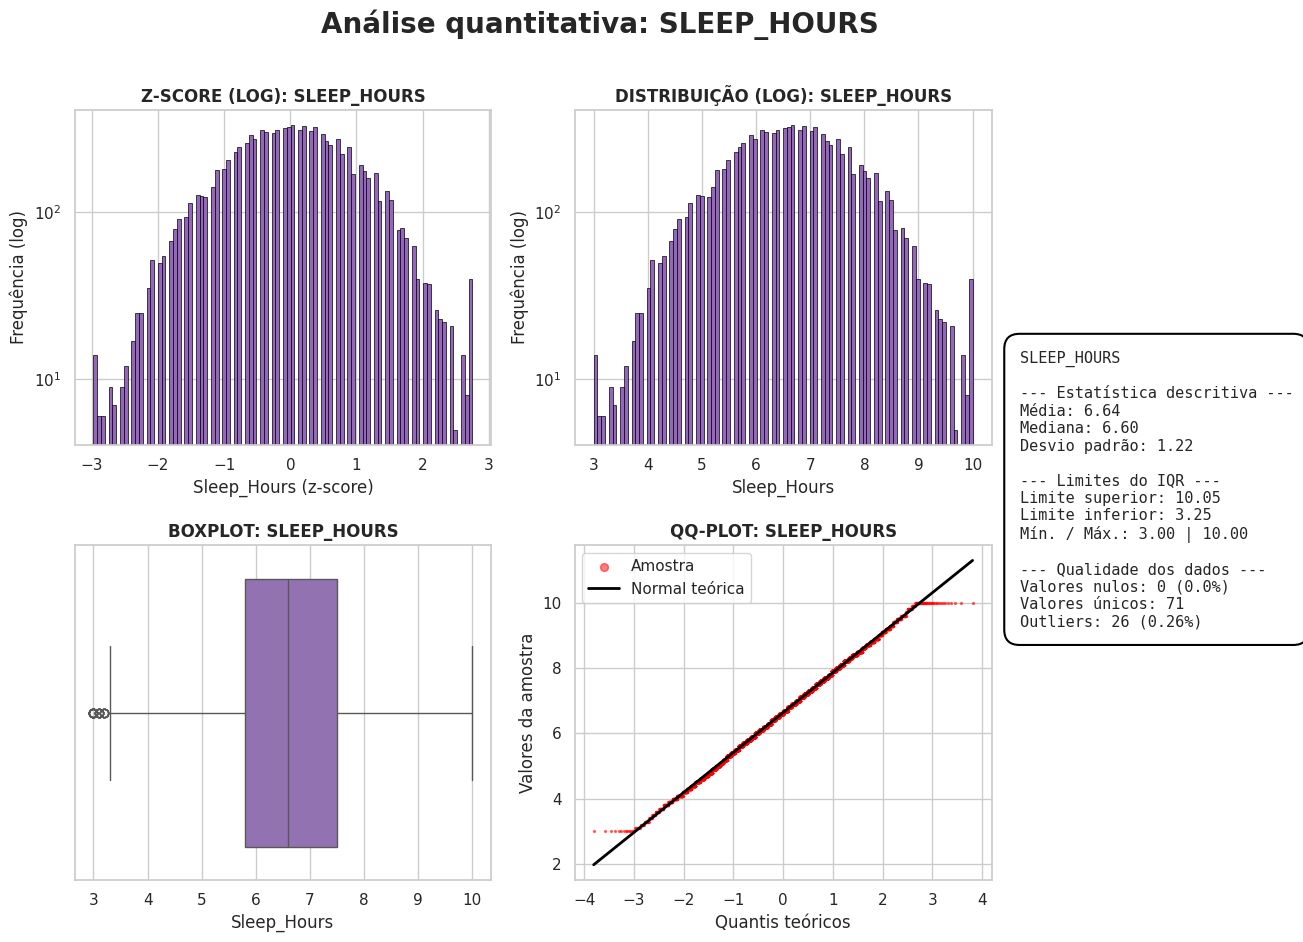

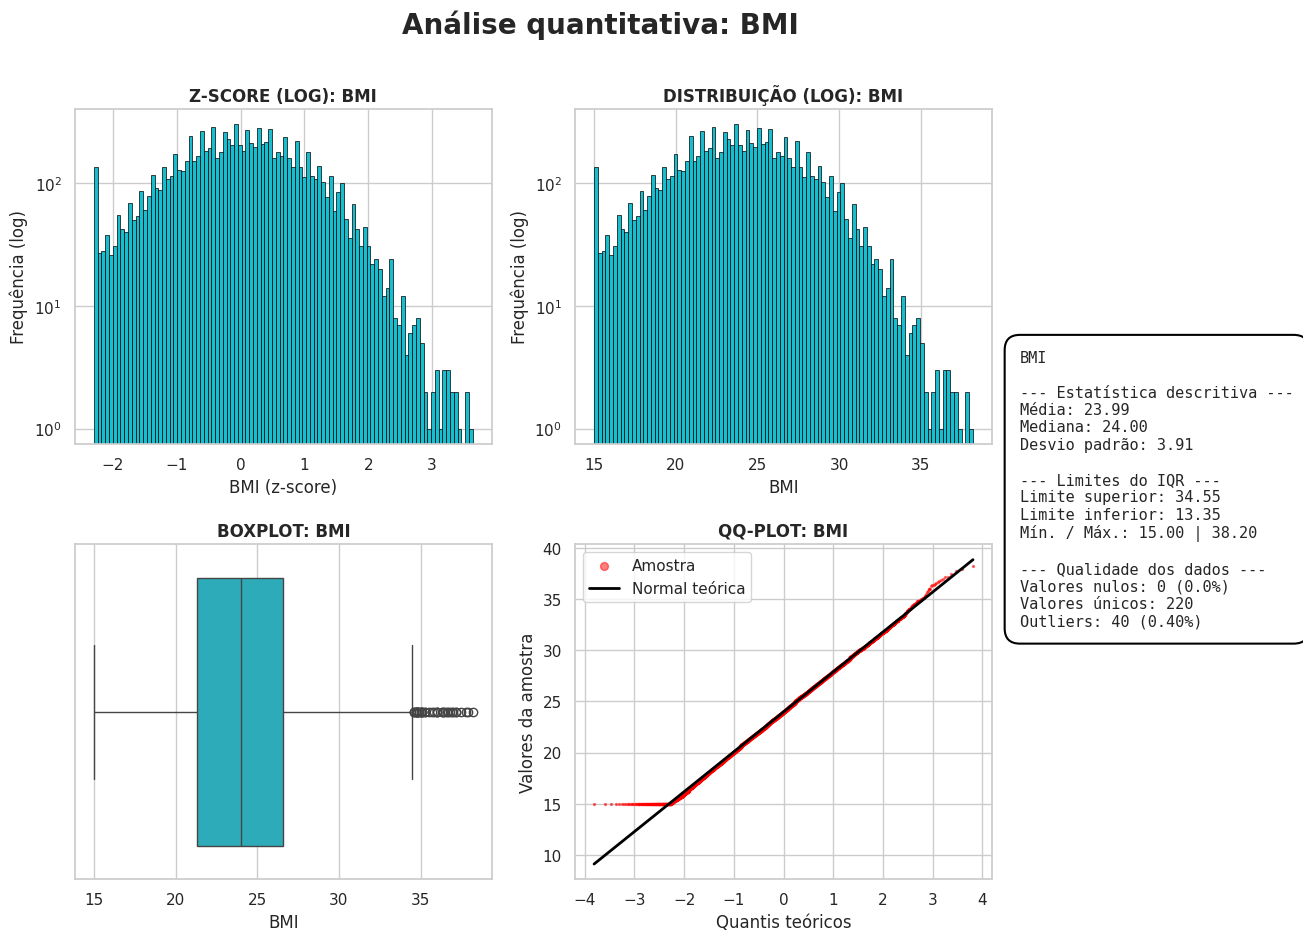

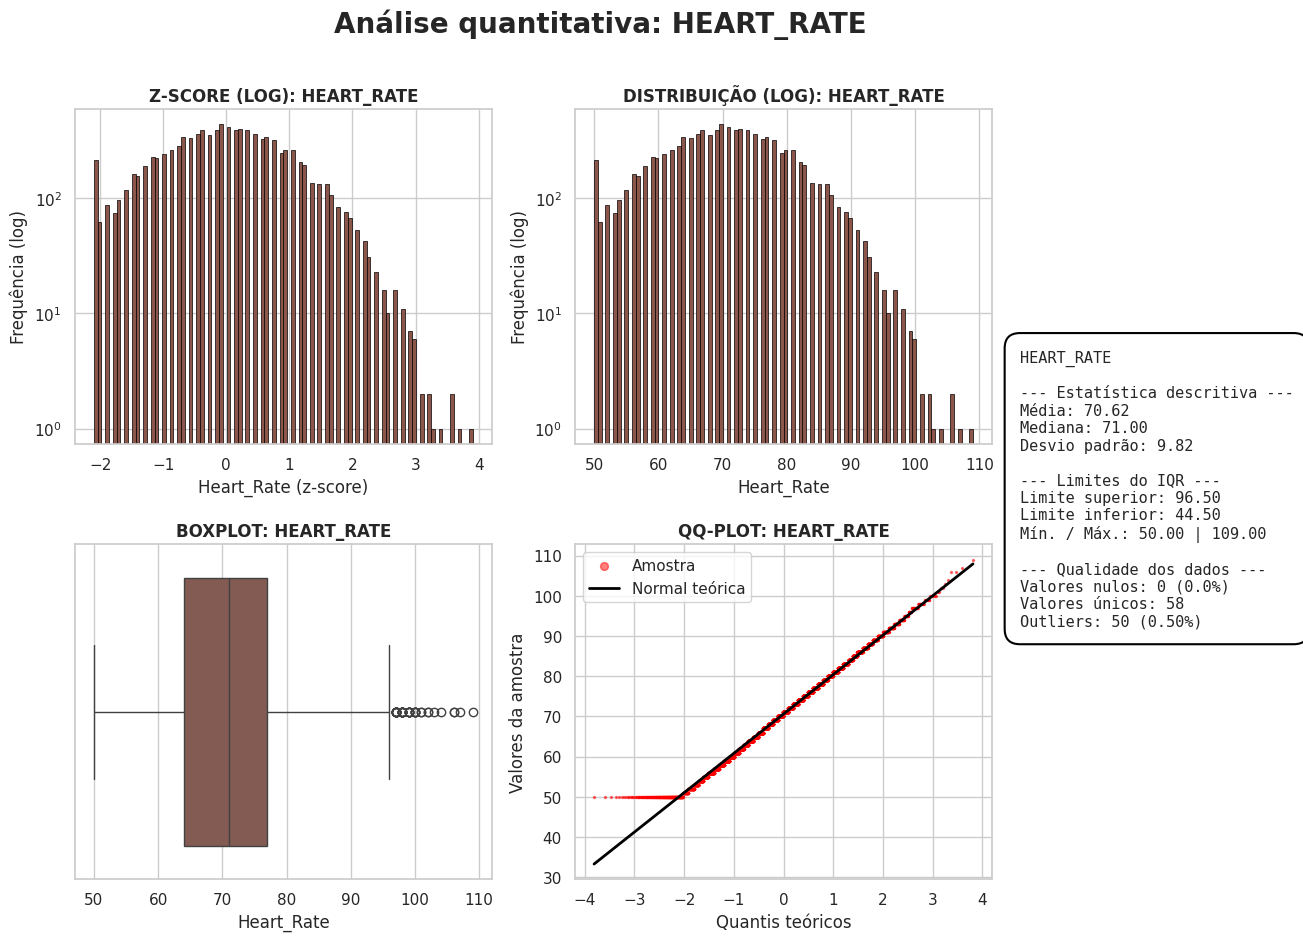

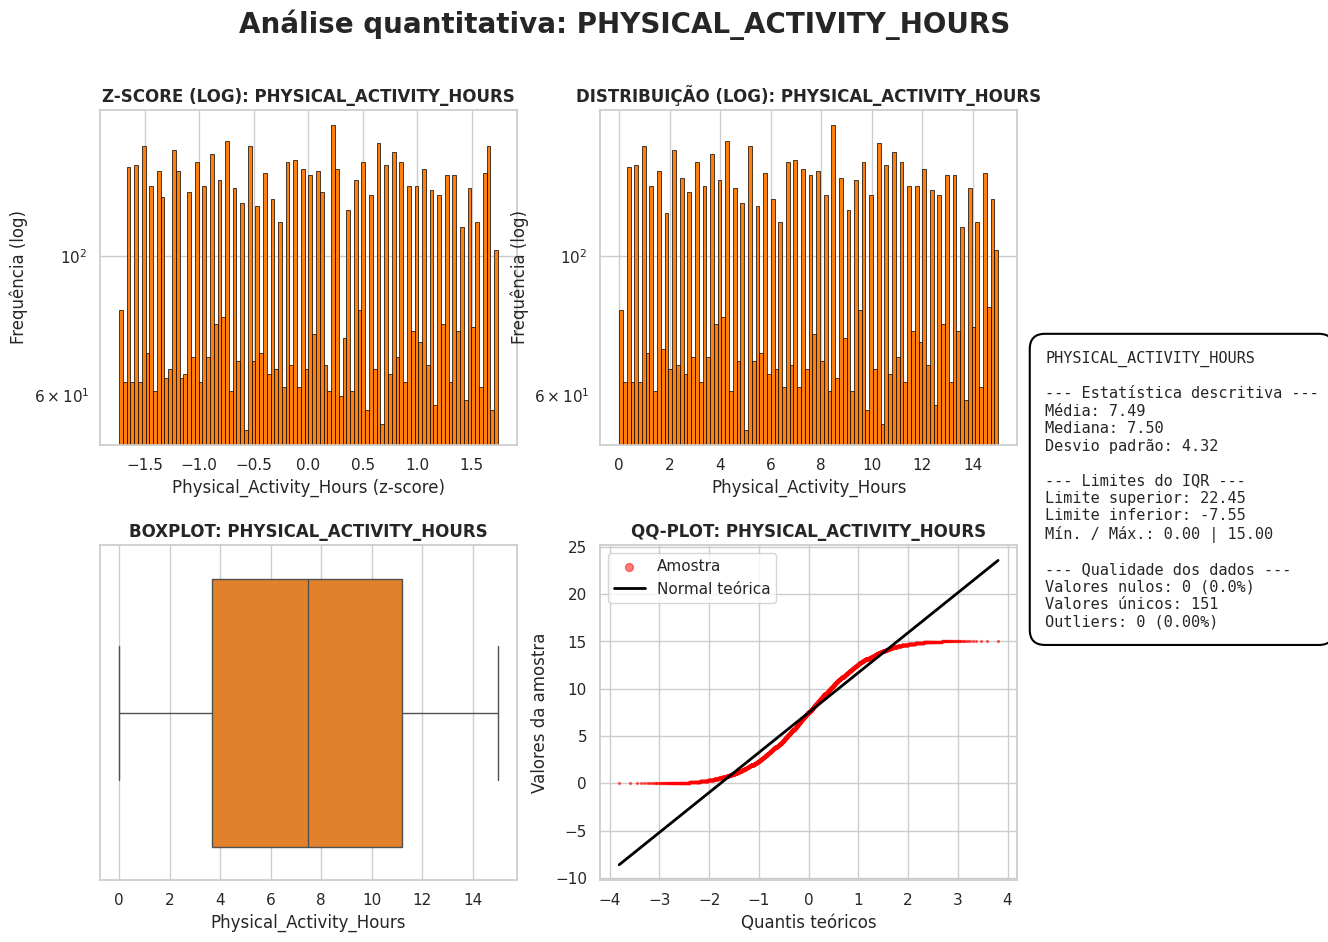

In [5]:
vizu.gerar_painel_quantitativo(df, variaveis_numericas)

##### INSIGHT:

- Não foram encontrados valores que indiquem erro de cadastro.
- As variáveis numéricas não têm valores nulos (os únicos ausentes da base estão em Health_Issues, tratados na 2.1).

#### 2.3.2 VARIÁVEIS CATEGÓRICAS

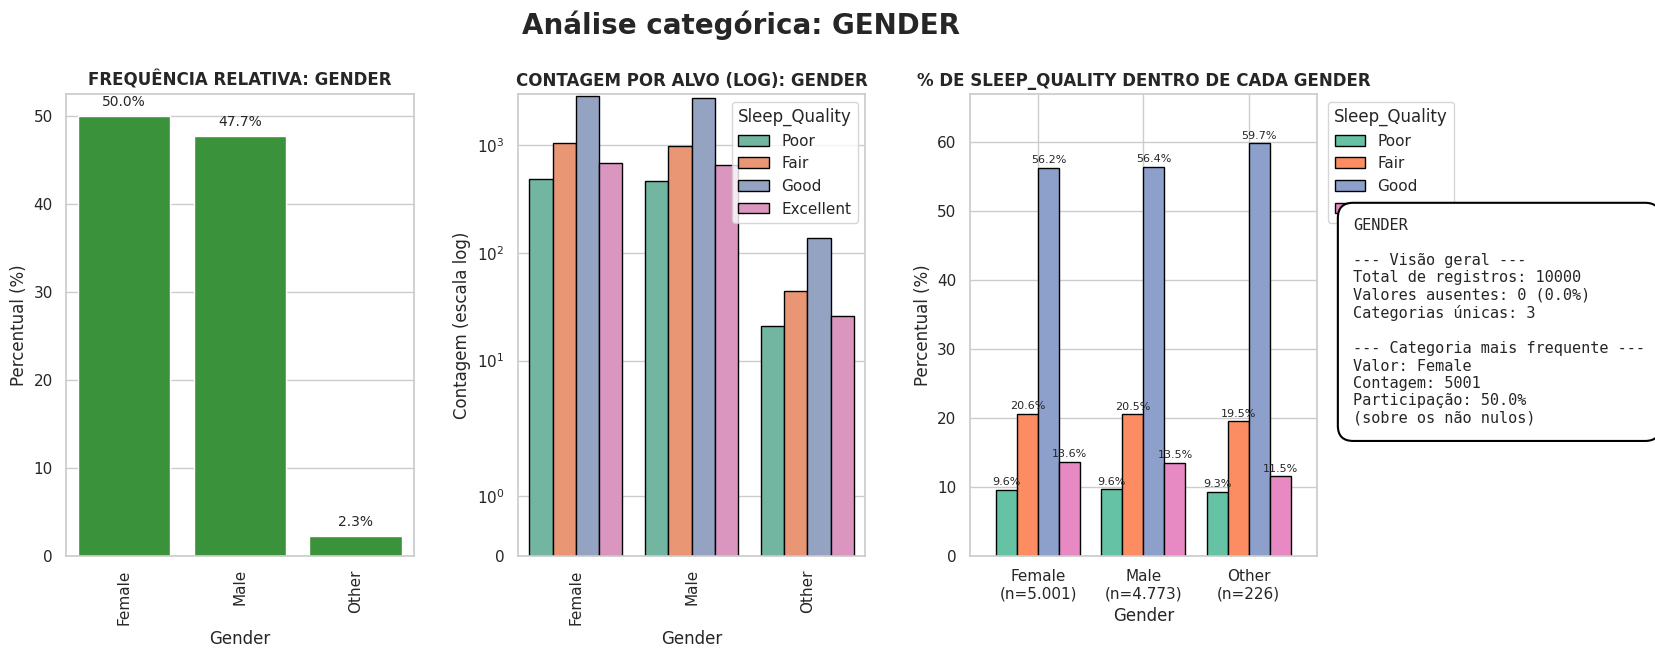

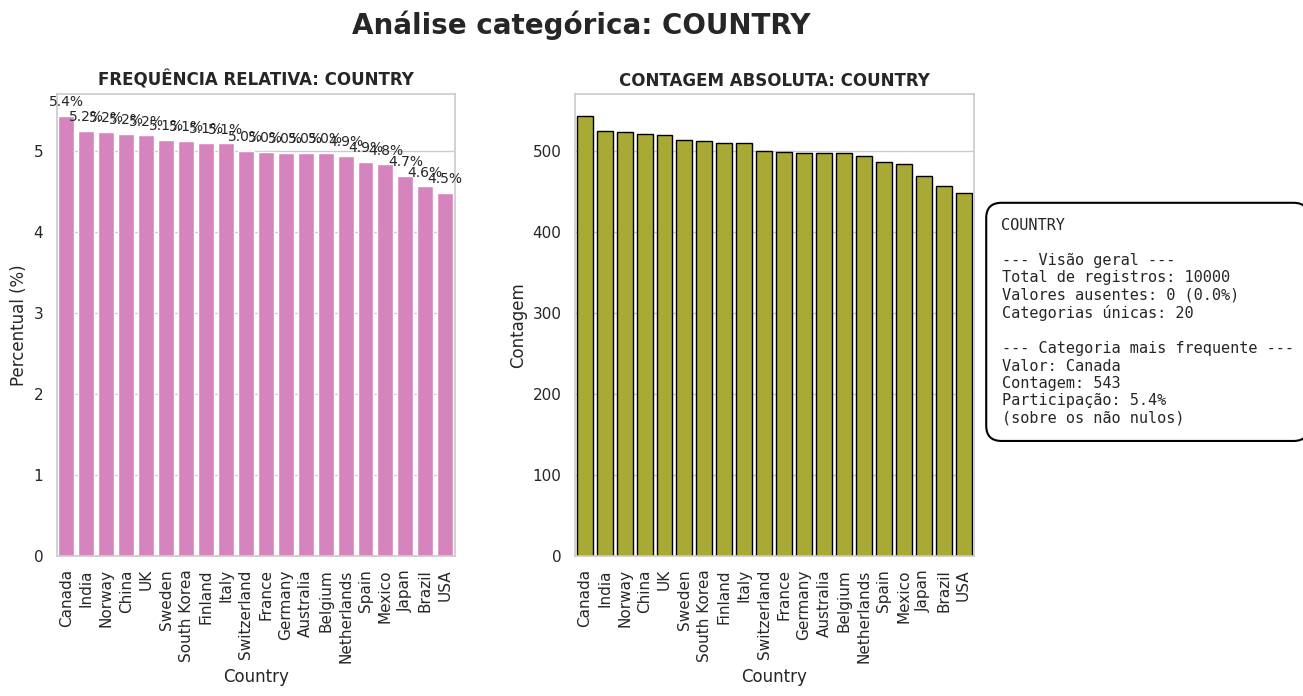

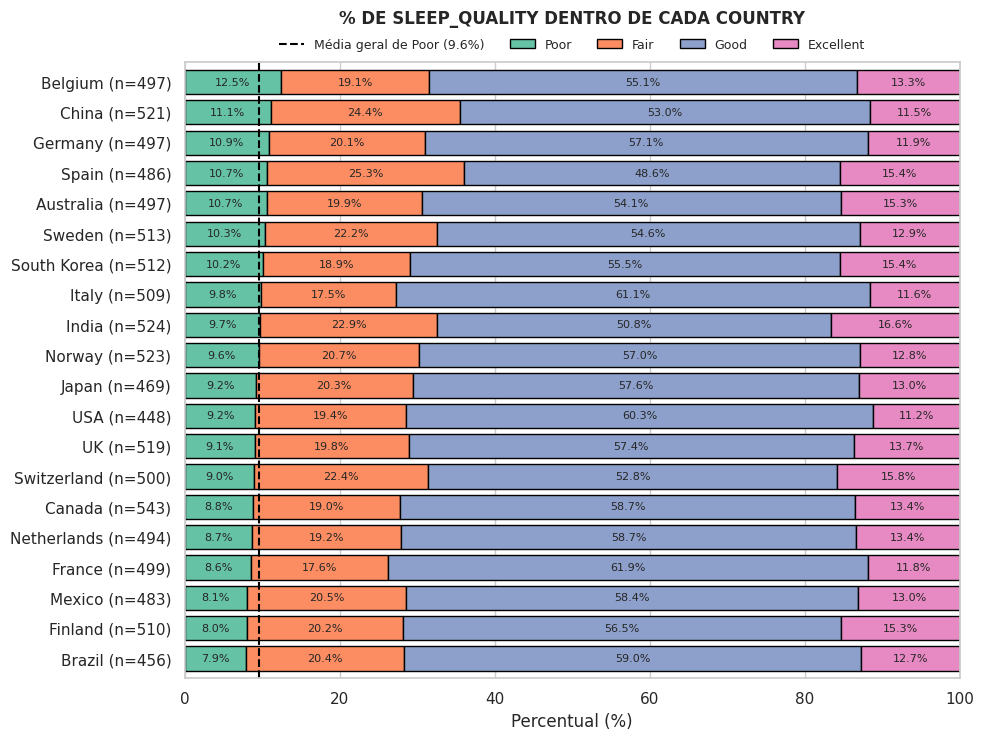

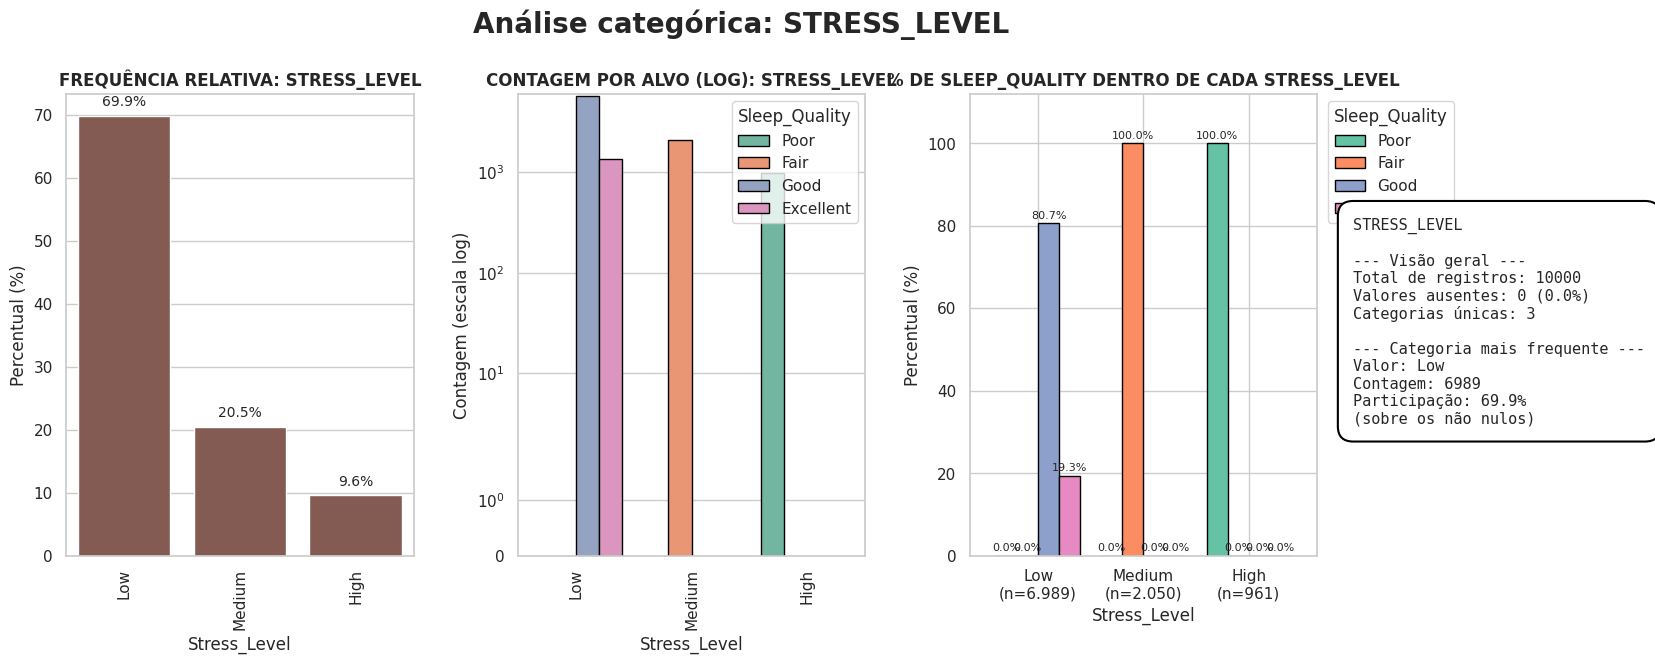

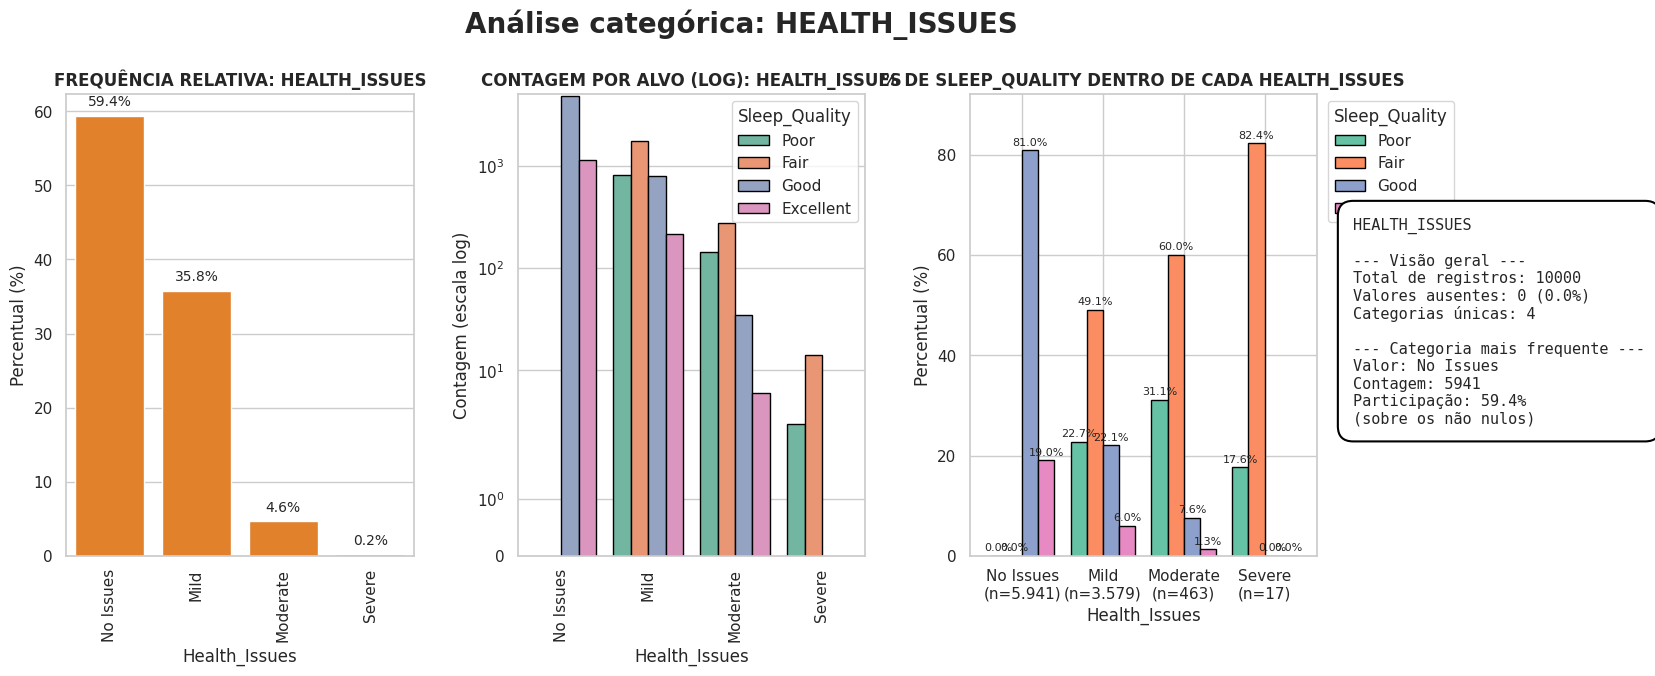

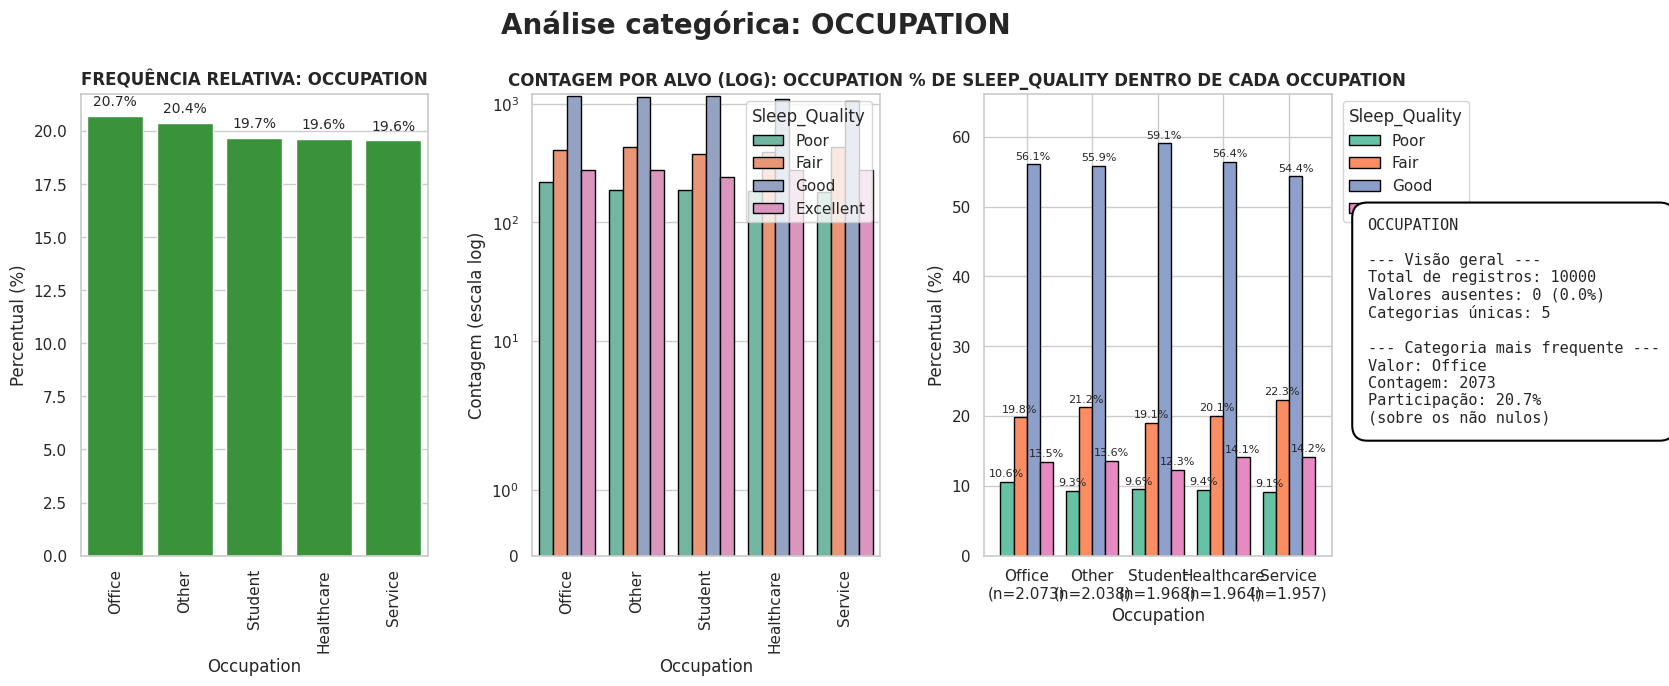

In [6]:
LIMITE_CATEGORIAS = 10

for variavel in variaveis_textuais:
    if variavel == ALVO:
        continue  # o alvo cruzado com ele mesmo não mostra nada

    if df[variavel].nunique() > LIMITE_CATEGORIAS:
        vizu.gerar_painel_categorico(df, variavel)  # frequência e contagem
        vizu.plotar_composicao_horizontal(df, variavel, ALVO, ordenar_por="Poor",
                                          ordem_classes=CLASSES)
        plt.show()  # mantém o gráfico logo abaixo do painel da mesma variável
    else:
        vizu.gerar_painel_categorico(df, variavel, alvo=ALVO)

#### 2.3.3 CORRELAÇÃO

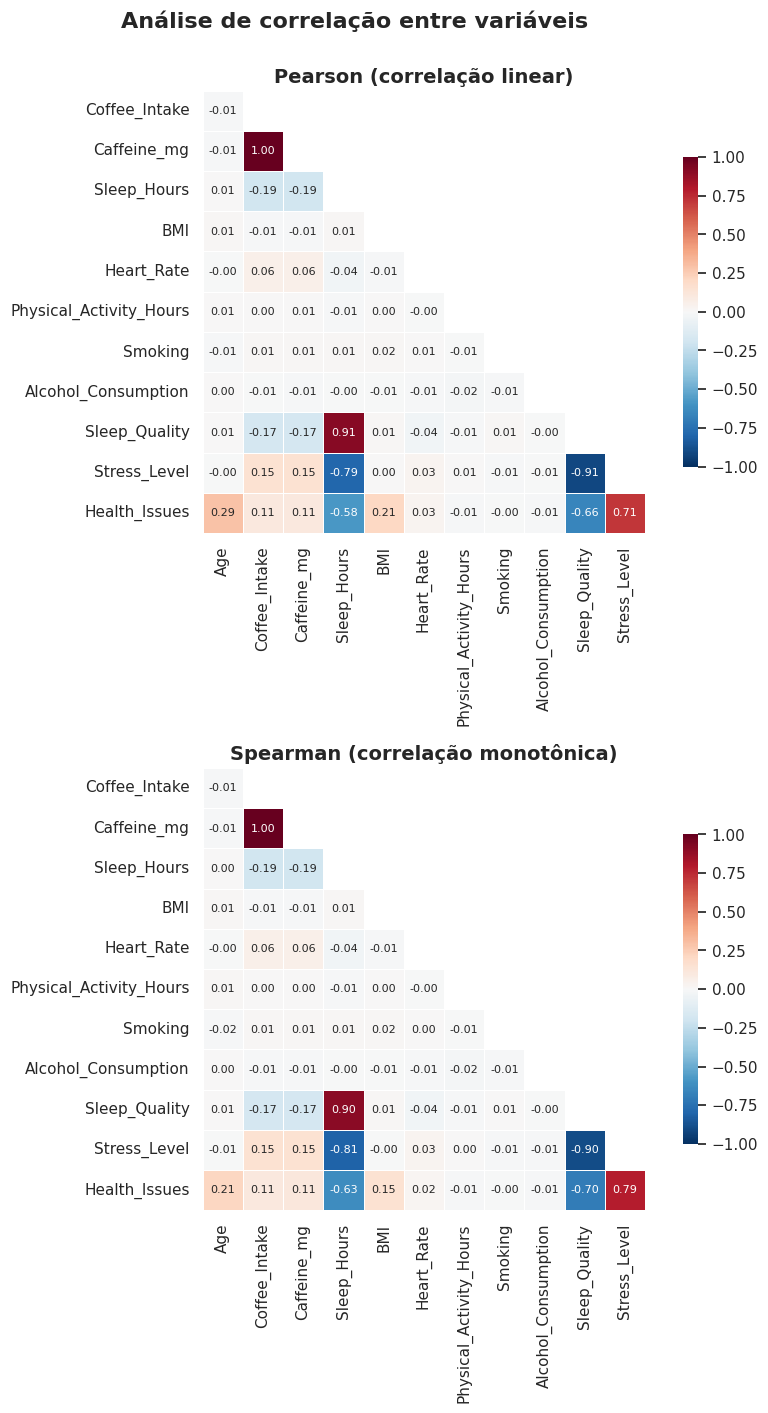

In [7]:
lista = vizu.plotar_heatmaps_correlacao(df, excluir=["ID"])

In [8]:
display(lista)

,Variavel_1,Variavel_2,Pearson,Spearman
0,Caffeine_mg,Coffee_Intake,0.999814,0.999782
1,Stress_Level,Sleep_Quality,-0.912108,-0.895799
2,Sleep_Quality,Sleep_Hours,0.911027,0.898966
3,Stress_Level,Sleep_Hours,-0.793459,-0.805247
4,Health_Issues,Stress_Level,0.711406,0.786943
5,Health_Issues,Sleep_Quality,-0.657957,-0.700197
6,Health_Issues,Sleep_Hours,-0.584061,-0.628372
7,Health_Issues,Age,0.291086,0.213923
8,Health_Issues,BMI,0.206306,0.149741
9,Sleep_Hours,Caffeine_mg,-0.190493,-0.190216


##### INSIGHTS

- Caffeine_mg e Coffee_Intake têm correlação praticamente perfeita (r = 0,9998): são a mesma informação.
- Sleep_Quality, Sleep_Hours e Stress_Level são fortemente correlacionadas entre si (|r| ≥ 0,79): as três medem o mesmo fenômeno (ver 2.3.4).
- Health_Issues acompanha estresse e sono (|r| entre 0,58 e 0,71) e tem correlação fraca com Age (0,29) e BMI (0,21).

#### 2.3.4 O ALVO É UMA FAIXA DE SLEEP_HOURS

Se Sleep_Quality for definida por faixas de horas de sono, as faixas de cada classe não se sobrepõem, e Stress_Level mapeia cada nível para classes fixas.

In [9]:
faixas = df.groupby(ALVO, observed=True)["Sleep_Hours"].agg(["min", "max", "count"])
display(faixas)

# As faixas podem se tocar no valor exato de cada limite (ex.: 5,0 h em Poor e em Fair):
# Sleep_Hours tem uma casa decimal, então 4,96 h (Poor) aparece como 5,0.
so_nos_limites = (faixas["min"].shift(-1).dropna() >= faixas["max"].iloc[:-1]).all()
print("As faixas só se tocam nos limites:", so_nos_limites)

limites = faixas["min"].iloc[1:].tolist()
na_fronteira = df["Sleep_Hours"].isin(limites)
print(f"Registros exatamente sobre um limite: {na_fronteira.sum()} ({na_fronteira.mean():.1%})")
display(pd.crosstab(df.loc[na_fronteira, "Sleep_Hours"], df.loc[na_fronteira, ALVO]))

pd.crosstab(df["Stress_Level"], df[ALVO])

,min,max,count
Sleep_Quality,,,
Poor,3.0,5.0,961
Fair,5.0,6.0,2050
Good,6.0,8.0,5637
Excellent,8.0,10.0,1352


As faixas só se tocam nos limites: True
Registros exatamente sobre um limite: 576 (5.8%)


Sleep_Quality,Poor,Fair,Good,Excellent
Sleep_Hours,,,,
5.0,67,58,0,0
6.0,0,133,141,0
8.0,0,0,93,84


Sleep_Quality,Poor,Fair,Good,Excellent
Stress_Level,,,,
Low,0,0,5637,1352
Medium,0,2050,0,0
High,961,0,0,0


##### INSIGHT

- **Sleep_Quality é uma regra sobre Sleep_Hours:** Poor até 5 h, Fair de 5 a 6 h, Good de 6 a 8 h e Excellent a partir de 8 h. As faixas só se encostam no valor exato de cada limite, o que é compatível com a classificação ter sido feita antes de as horas serem arredondadas para uma casa decimal.
- **Stress_Level segue a mesma regra:** High = Poor, Medium = Fair, Low = Good ou Excellent, sem nenhuma exceção.
- As duas variáveis são o próprio alvo medido de outro jeito e **não podem ser usadas para explicá-lo** (ver seção 3).

## **2.4 TESTES ESTATÍSTICOS**


In [10]:
resultados = []

for variavel in variaveis_numericas:
    for grupo in variaveis_categoricas:
        if df[grupo].nunique() == 2:
            r = testes.comparar_dois_grupos(df, variavel, grupo, verbose=False)
        else:
            r, _ = testes.comparar_n_grupos(df, variavel, grupo, verbose=False)
        r["grupo"] = grupo
        resultados.append(r)

tabela = pd.DataFrame(resultados)[
    ["variavel", "grupo", "metrica_efeito", "p_valor", "tamanho_efeito", "magnitude"]
]
_, tabela["p_ajustado"], _, _ = multipletests(tabela["p_valor"], method="fdr_bh")
tabela["relevante"] = (tabela["p_ajustado"] < 0.05) & (tabela["magnitude"] != "DESPREZÍVEL")

In [11]:
resultados_cat = []

for var1, var2 in combinations(variaveis_categoricas, 2):
    r, _ = testes.comparar_categoricas(df, var1, var2, verbose=False)
    resultados_cat.append(r)

tabela_cat = pd.DataFrame(resultados_cat)[
    ["variavel", "grupo", "p_valor", "cramers_v", "magnitude"]
]
_, tabela_cat["p_ajustado"], _, _ = multipletests(tabela_cat["p_valor"], method="fdr_bh")

tabela_cat.sort_values("cramers_v", ascending=False).head(15)

,variavel,grupo,p_valor,cramers_v,magnitude,p_ajustado
13,Sleep_Quality,Stress_Level,0.000000,1.000000,GRANDE,0.000000
18,Stress_Level,Health_Issues,0.000000,0.565329,GRANDE,0.000000
14,Sleep_Quality,Health_Issues,0.000000,0.461654,MÉDIA,0.000000
11,Country,Smoking,0.053296,0.054666,DESPREZÍVEL,0.213185
9,Country,Health_Issues,0.023896,0.051643,DESPREZÍVEL,0.133815
7,Country,Sleep_Quality,0.104526,0.048555,DESPREZÍVEL,0.353360
8,Country,Stress_Level,0.295652,0.045914,DESPREZÍVEL,0.521302
10,Country,Occupation,0.316505,0.045095,DESPREZÍVEL,0.521302
12,Country,Alcohol_Consumption,0.639687,0.040327,DESPREZÍVEL,0.770503
0,Gender,Country,0.792772,0.039198,DESPREZÍVEL,0.853754


In [ ]:
dois_grupos = tabela["grupo"].isin(variaveis_binarias)

print("Variáveis numéricas x Sleep_Quality (o que responde à pergunta do projeto):")
display(tabela[tabela["grupo"] == ALVO].sort_values("tamanho_efeito", ascending=False))

print("3 ou mais grupos (Epsilon² / Eta²), maiores efeitos:")
display(tabela[~dois_grupos].sort_values("tamanho_efeito", ascending=False).head(10))

print("2 grupos (Rank-biserial / Cohen's d), maiores efeitos:")
display(tabela[dois_grupos].sort_values("tamanho_efeito", ascending=False, key=abs).head(10))

Variáveis numéricas x Sleep_Quality (o que responde à pergunta do projeto):


,variavel,grupo,metrica_efeito,p_valor,tamanho_efeito,magnitude,p_ajustado,relevante
26,Sleep_Hours,Sleep_Quality,Epsilon²,0.000000e+00,0.808083,GRANDE,0.000000e+00,True
18,Caffeine_mg,Sleep_Quality,Epsilon²,9.369475e-66,0.030186,PEQUENA,8.744843e-65,True
10,Coffee_Intake,Sleep_Quality,Epsilon²,1.123118e-65,0.030150,PEQUENA,8.984942e-65,True
42,Heart_Rate,Sleep_Quality,Epsilon²,7.431821e-04,0.001390,DESPREZÍVEL,3.468183e-03,False
34,BMI,Sleep_Quality,Epsilon²,9.860344e-02,0.000328,DESPREZÍVEL,3.248113e-01,False
2,Age,Sleep_Quality,Epsilon²,6.651904e-01,0.000000,DESPREZÍVEL,8.305816e-01,False
50,Physical_Activity_Hours,Sleep_Quality,Epsilon²,5.411471e-01,0.000000,DESPREZÍVEL,7.774728e-01,False


3 ou mais grupos (Epsilon² / Eta²), maiores efeitos:


,variavel,grupo,metrica_efeito,p_valor,tamanho_efeito,magnitude,p_ajustado,relevante
26,Sleep_Hours,Sleep_Quality,Epsilon²,0.000000e+00,0.808083,GRANDE,0.000000e+00,True
27,Sleep_Hours,Stress_Level,Epsilon²,0.000000e+00,0.648353,GRANDE,0.000000e+00,True
28,Sleep_Hours,Health_Issues,Epsilon²,0.000000e+00,0.395728,GRANDE,0.000000e+00,True
4,Age,Health_Issues,Epsilon²,4.439891e-147,0.067732,MÉDIA,6.215848e-146,True
36,BMI,Health_Issues,Epsilon²,9.513459e-79,0.036190,PEQUENA,1.065507e-77,True
18,Caffeine_mg,Sleep_Quality,Epsilon²,9.369475e-66,0.030186,PEQUENA,8.744843e-65,True
10,Coffee_Intake,Sleep_Quality,Epsilon²,1.123118e-65,0.030150,PEQUENA,8.984942e-65,True
19,Caffeine_mg,Stress_Level,Epsilon²,6.425906e-49,0.022000,PEQUENA,4.498134e-48,True
11,Coffee_Intake,Stress_Level,Epsilon²,7.348904e-49,0.021973,PEQUENA,4.572651e-48,True
20,Caffeine_mg,Health_Issues,Epsilon²,3.814730e-26,0.011847,PEQUENA,2.136249e-25,True


2 grupos (Rank-biserial / Cohen's d), maiores efeitos:


,variavel,grupo,metrica_efeito,p_valor,tamanho_efeito,magnitude,p_ajustado,relevante
55,Physical_Activity_Hours,Alcohol_Consumption,Rank-biserial,0.056560,-0.024007,DESPREZÍVEL,0.211158,False
6,Age,Smoking,Rank-biserial,0.124575,-0.022137,DESPREZÍVEL,0.365487,False
38,BMI,Smoking,Rank-biserial,0.130531,0.021808,DESPREZÍVEL,0.365487,False
22,Caffeine_mg,Smoking,Rank-biserial,0.317609,0.014414,DESPREZÍVEL,0.670968,False
14,Coffee_Intake,Smoking,Rank-biserial,0.320883,0.014313,DESPREZÍVEL,0.670968,False
30,Sleep_Hours,Smoking,Rank-biserial,0.323503,0.014236,DESPREZÍVEL,0.670968,False
47,Heart_Rate,Alcohol_Consumption,Rank-biserial,0.321684,-0.012472,DESPREZÍVEL,0.670968,False
23,Caffeine_mg,Alcohol_Consumption,Rank-biserial,0.391406,-0.010791,DESPREZÍVEL,0.754202,False
54,Physical_Activity_Hours,Smoking,Rank-biserial,0.457979,-0.010705,DESPREZÍVEL,0.754318,False
15,Coffee_Intake,Alcohol_Consumption,Rank-biserial,0.404037,-0.010503,DESPREZÍVEL,0.754202,False


## **2.5 INSIGHTS**

- Sleep_Quality é uma faixa de Sleep_Hours, e Stress_Level segue a mesma regra (2.3.4).
- Caffeine_mg ≈ 95 × Coffee_Intake (r = 0,9998): são a mesma informação.
- Health_Issues "No Issues" só aparece em Good/Excellent.
- O gênero "Other" tem 2,3% dos registros, então as taxas desse grupo são instáveis.

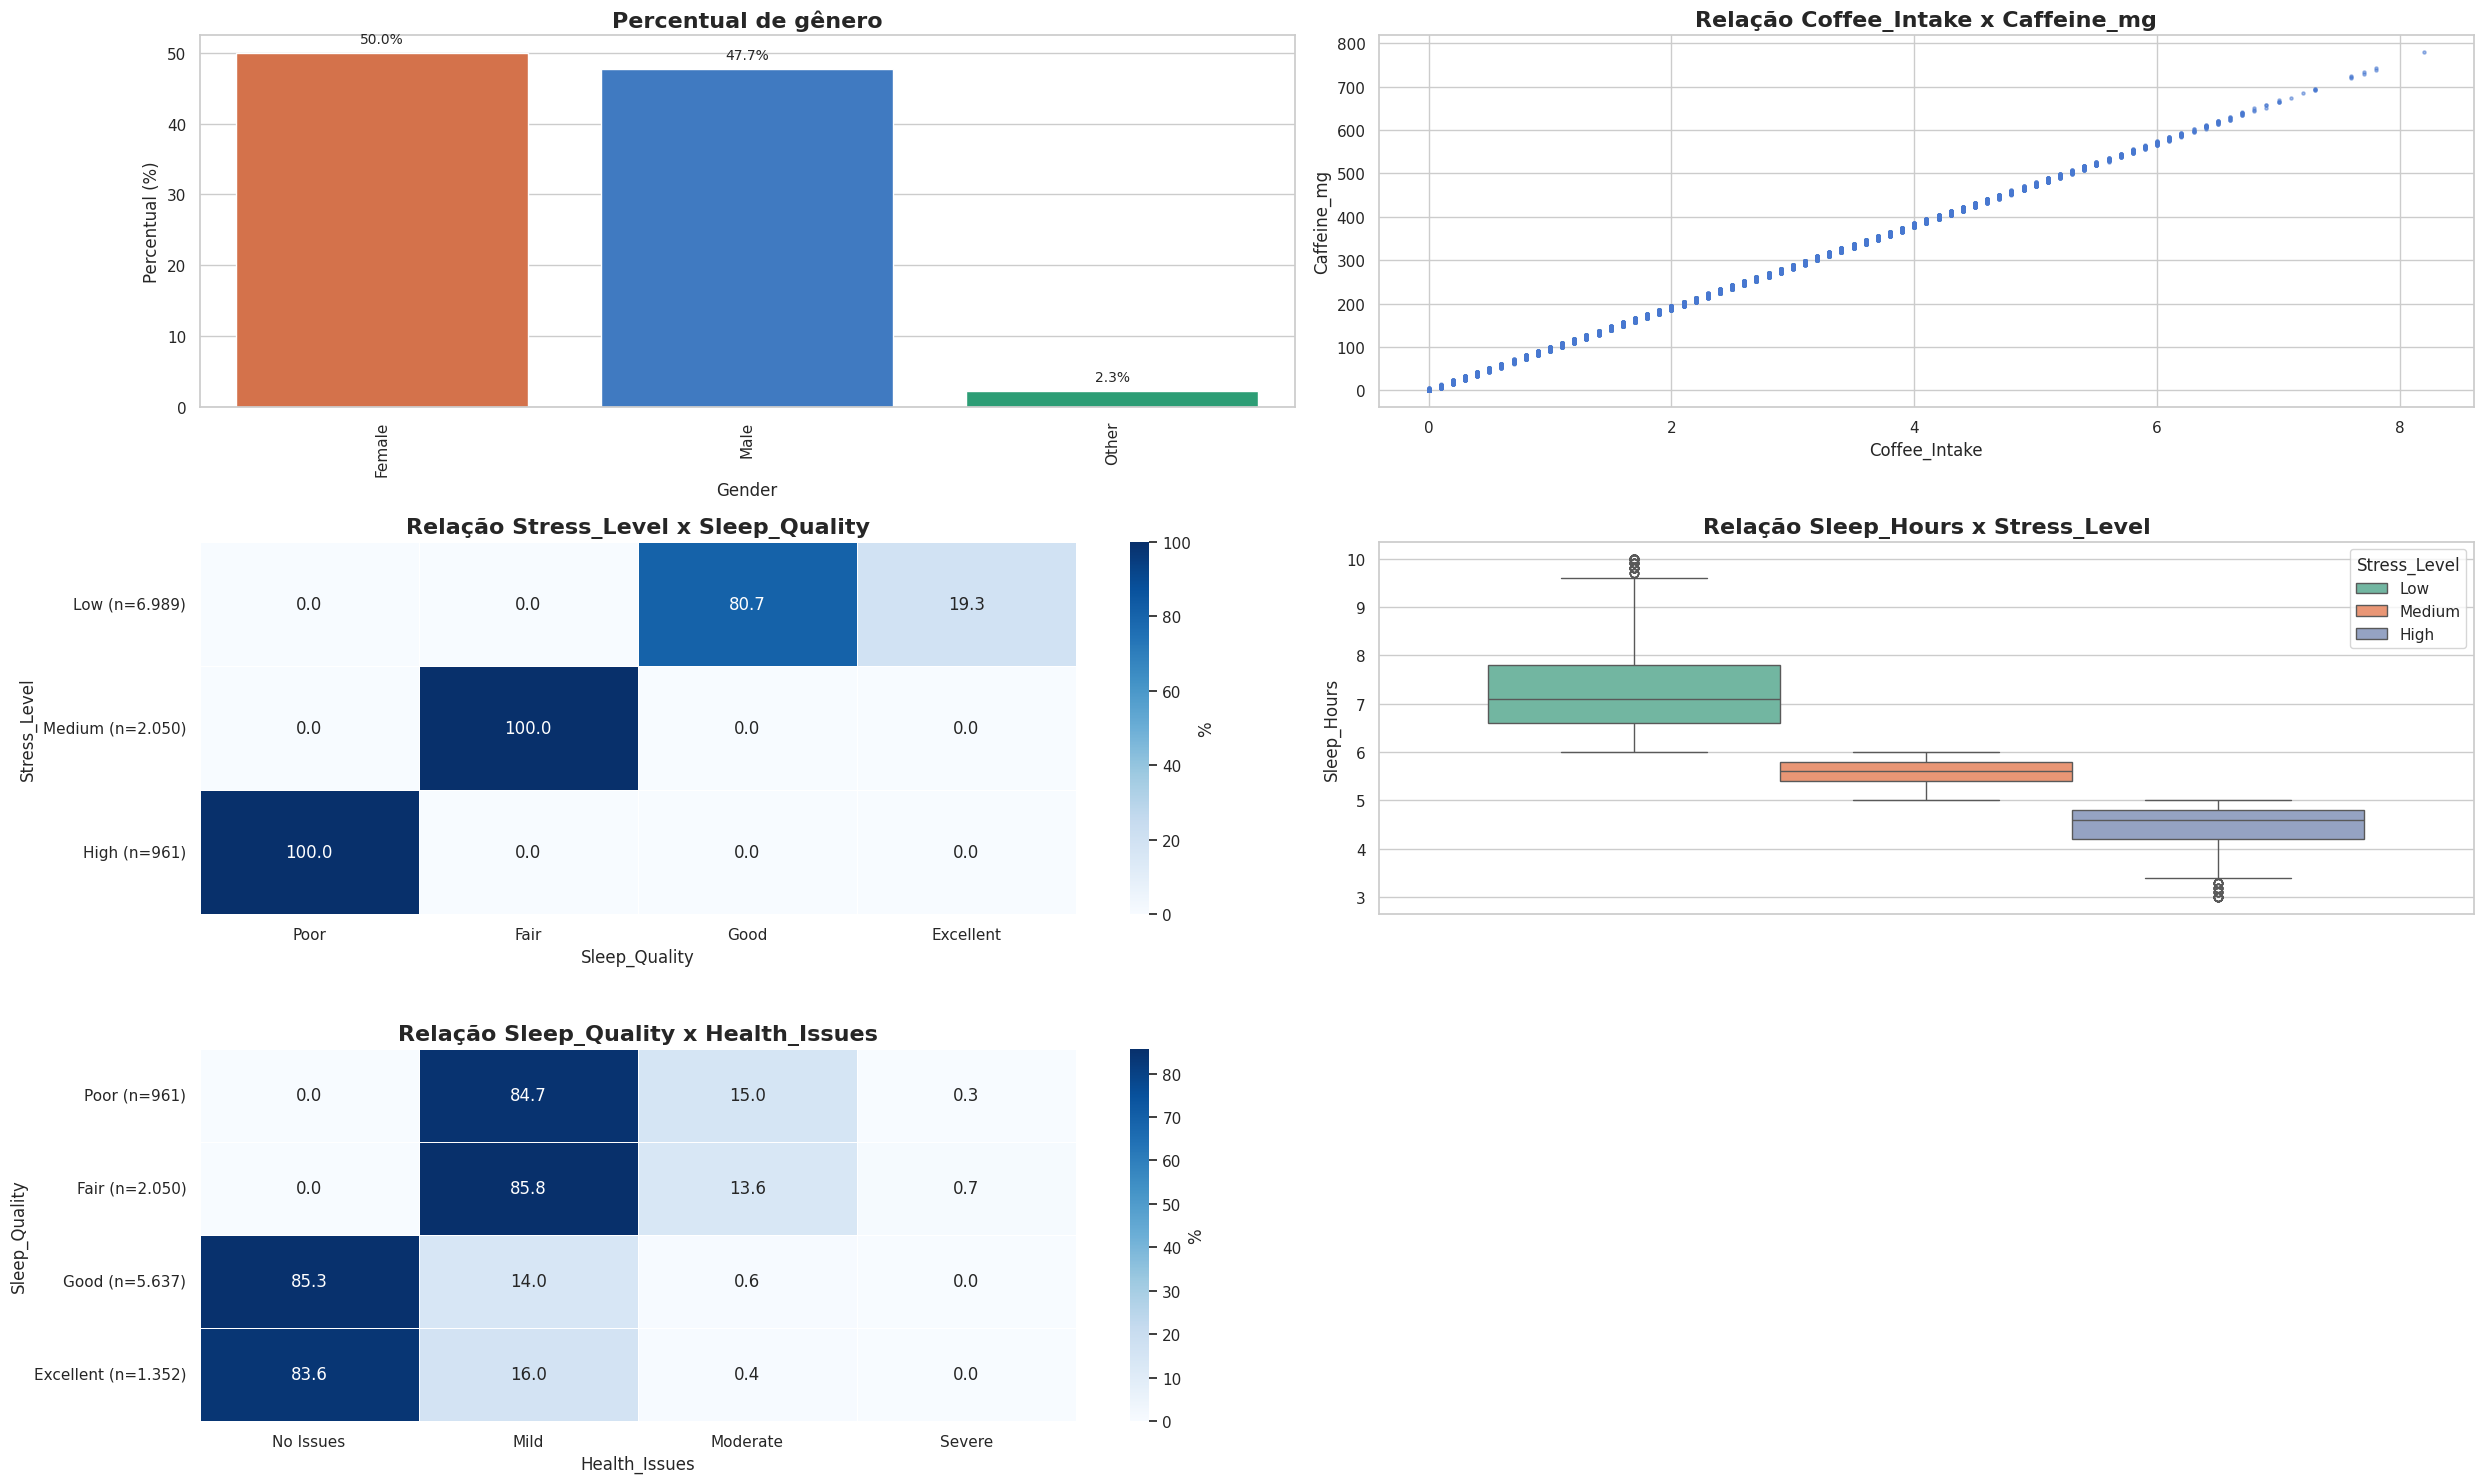

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(25, 15))

cores_genero = {
    "Female": "#eb6834",  # laranja
    "Male":   "#2a78d6",  # azul
    "Other":  "#1baf7a",  # verde-água
}


# PRIMEIRO GRÁFICO
vizu.plotar_barras_frequencia_variavel(df, variavel="Gender", ax=axes[0, 0], mapa_cores=cores_genero)
axes[0, 0].set_title("Percentual de gênero", fontweight="bold", fontsize=16)  


# SEGUNDO GRÁFICO
vizu.plotar_scatter(df, 'Coffee_Intake', 'Caffeine_mg', ax=axes[0, 1])
axes[0, 1].set_title('Relação Coffee_Intake x Caffeine_mg', fontweight='bold', fontsize=16)


# TERCEIRO GRÁFICO
vizu.plotar_heatmaps_cruzada(df, 'Stress_Level', 'Sleep_Quality', ax=axes[1, 0])
axes[1, 0].set_title('Relação Stress_Level x Sleep_Quality', fontweight='bold', fontsize=16)


# QUARTO GRÁFICO
vizu.plotar_boxplot(df, variavel='Sleep_Hours', ax=axes[1,1], orientacao='v', hue='Stress_Level')
axes[1, 1].set_title('Relação Sleep_Hours x Stress_Level', fontweight='bold', fontsize=16)


# QUINTO GRÁFICO
vizu.plotar_heatmaps_cruzada(df, 'Sleep_Quality', 'Health_Issues', ax=axes[2, 0])
axes[2, 0].set_title('Relação Sleep_Quality x Health_Issues', fontweight='bold', fontsize=16)

axes[2, 1].axis("off")  # 5 gráficos numa grade de 6

plt.tight_layout()
plt.show()

**Redundância.** **Sleep_Hours**, **Sleep_Quality** e **Stress_Level** carregam a mesma informação (Cramér's V = 1,000 entre as categóricas: cada nível de estresse corresponde a faixas fixas de qualidade do sono). **Coffee_Intake** e **Caffeine_mg** também coincidem (r = 0,9998) e produzem resultados idênticos em todos os testes.

**Sinal remanescente.** **Coffee_Intake** apresenta gradiente monotônico e limpo entre os níveis de **Sleep_Quality** (Excellent 2,0 xícaras; Poor 3,0), com todos os pares diferindo entre si. Mas o efeito é pequeno: epsilon² = 0,030, cerca de 3% da variação explicada. A direção sustenta a hipótese do projeto; a magnitude, não.

**Natureza dos dados.** O padrão — poucas fontes de estrutura, todas derivadas umas das outras, e ruído no restante — é característico de dados sintéticos gerados a partir de variáveis-semente. As conclusões valem como demonstração de método, não como evidência sobre a relação real entre café e sono.

# **3. PREPARAÇÃO DE DADOS**

Variáveis retiradas do modelo:

- **Definem o alvo:** Sleep_Hours e Stress_Level (2.3.4). Usá-las seria prever o alvo a partir dele mesmo.
- **Consequência provável:** Health_Issues. "No Issues" só aparece em Good/Excellent; o problema de saúde tende a ser efeito do sono ruim (ou, no dataset sintético, gerado a partir dele), e não um hábito que o explique.
- **Redundante:** Caffeine_mg (≈ 95 × Coffee_Intake).
- **Sem informação:** ID.

In [14]:
DEFINEM_O_ALVO        = ["Sleep_Hours", "Stress_Level"]   # o alvo é uma regra sobre elas (2.3.4)
CONSEQUENCIA_PROVAVEL = ["Health_Issues"]                 # "No Issues" só aparece em Good/Excellent
REDUNDANTES           = ["Caffeine_mg"]                   # ≈ 95 × Coffee_Intake, r = 0,9998
SEM_INFO              = ["ID"]

dados = df.drop(columns=DEFINEM_O_ALVO + CONSEQUENCIA_PROVAVEL + REDUNDANTES + SEM_INFO).copy()

for col in ["Gender", "Country", "Occupation"]:
    dados[col] = dados[col].astype("category")

y = dados[ALVO].cat.codes.astype(int)
X = dados.drop(columns=[ALVO])

assert (y >= 0).all(), "Há valores nulos no alvo."

print(f"X: {X.shape[0]} linhas x {X.shape[1]} colunas")
print(f"Features: {', '.join(X.columns)}")
print(f"\nDistribuição do alvo:\n{y.value_counts().sort_index().rename(dict(enumerate(CLASSES)))}")

X: 10000 linhas x 10 colunas
Features: Age, Gender, Country, Coffee_Intake, BMI, Heart_Rate, Physical_Activity_Hours, Occupation, Smoking, Alcohol_Consumption

Distribuição do alvo:
Poor          961
Fair         2050
Good         5637
Excellent    1352
Name: count, dtype: int64


# **4. MODELAGEM**

As classes são desbalanceadas (Good tem 5.637 casos, Poor tem 961). Por isso:

- a métrica é **F1-macro**, que pesa todas as classes igualmente — acurácia premiaria um modelo que só prevê Good;
- class_weight="balanced" força o modelo a considerar as minoritárias;
- o DummyClassifier (chute estratificado) estabelece o piso de comparação.

Protocolo de avaliação:

- 25% da base fica separada como **teste** e só é usada uma vez, no fim;
- as configurações do LightGBM são comparadas por **validação cruzada estratificada (5 folds)** nos 75% restantes;
- o ganho sobre o chute é calculado fold a fold (mesmas divisões para os dois), com média ± desvio, para saber se ele se distingue da variação entre folds.

In [15]:
X_dev, X_te, y_dev, y_te = train_test_split(X, y, test_size=.25, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def lgbm(folhas, minimo):
    return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=folhas,
                              min_child_samples=minimo, class_weight="balanced",
                              random_state=42, verbose=-1)

f1_base = cross_val_score(DummyClassifier(strategy="stratified", random_state=42),
                          X_dev, y_dev, cv=cv, scoring="f1_macro")
print(f"Baseline (chute estratificado): F1 {f1_base.mean():.3f} ± {f1_base.std():.3f}\n")

resultados = {}
for folhas, minimo in [(31, 30), (15, 100), (7, 300)]:
    cv_res = cross_validate(lgbm(folhas, minimo), X_dev, y_dev, cv=cv,
                            scoring="f1_macro", return_train_score=True)
    s = cv_res["test_score"]
    resultados[(folhas, minimo)] = s
    ganho = s - f1_base   # mesmo fold, comparação pareada
    print(f"folhas={folhas:2d} min={minimo:3d} | treino {cv_res['train_score'].mean():.3f} "
          f"| validação {s.mean():.3f} ± {s.std():.3f} | ganho {ganho.mean():+.3f} ± {ganho.std():.3f}")

melhor = max(resultados, key=lambda k: resultados[k].mean())
modelo = lgbm(*melhor).fit(X_dev, y_dev)
print(f"\nEscolhido: folhas={melhor[0]}, min={melhor[1]}")
print("Teste (avaliado uma única vez):", round(f1_score(y_te, modelo.predict(X_te), average="macro"), 3))

Baseline (chute estratificado): F1 0.252 ± 0.013

folhas=31 min= 30 | treino 0.910 | validação 0.270 ± 0.008 | ganho +0.019 ± 0.020
folhas=15 min=100 | treino 0.676 | validação 0.257 ± 0.015 | ganho +0.006 ± 0.022
folhas= 7 min=300 | treino 0.446 | validação 0.251 ± 0.007 | ganho -0.000 ± 0.017

Escolhido: folhas=31, min=30
Teste (avaliado uma única vez): 0.265


**Leitura.** Nas configurações mais flexíveis, o F1 de treino fica muito acima do de validação: o modelo memoriza o treino. Regularizar (num_leaves de 31 para 7, min_child_samples de 30 para 300) derruba o F1 de treino e aproxima as duas curvas, mas a validação não melhora (0,270 → 0,257 → 0,251) e fica sempre colada no chute (0,252).

O overfitting é sintoma, não causa: o modelo memoriza porque não há padrão generalizável a aprender. Isso é consistente com os testes estatísticos, que encontraram um único efeito relevante (Coffee_Intake, ~3% da variação) depois de retiradas as variáveis que definem o alvo.

# **5. AVALIAÇÃO**

In [16]:
print(classification_report(y_te, modelo.predict(X_te),
                            target_names=CLASSES, zero_division=0))

              precision    recall  f1-score   support

        Poor       0.10      0.12      0.11       240
        Fair       0.21      0.24      0.22       513
        Good       0.58      0.49      0.53      1409
   Excellent       0.17      0.22      0.19       338

    accuracy                           0.37      2500
   macro avg       0.27      0.27      0.26      2500
weighted avg       0.40      0.37      0.38      2500



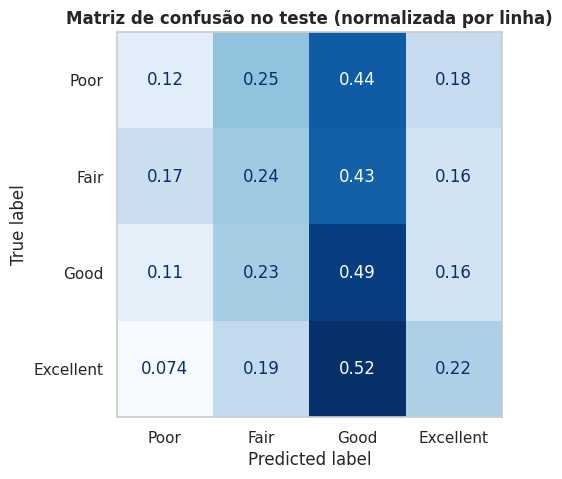

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(modelo, X_te, y_te, display_labels=CLASSES,
                                      normalize="true", cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Matriz de confusão no teste (normalizada por linha)", fontweight="bold")
ax.grid(False)
plt.show()

In [18]:
# Quanto o F1 cai quando cada coluna é embaralhada (perto de zero = a coluna não ajuda)
imp = permutation_importance(modelo, X_te, y_te, scoring="f1_macro", n_repeats=10, random_state=42)
pd.Series(imp.importances_mean, index=X_te.columns, name="queda_no_f1").sort_values(ascending=False)

Coffee_Intake              2.591113e-02
Occupation                 8.232808e-03
Country                    4.695185e-03
BMI                        2.180674e-03
Alcohol_Consumption        9.972738e-04
Physical_Activity_Hours    8.274689e-07
Smoking                   -4.153623e-04
Gender                    -2.267135e-03
Heart_Rate                -4.798151e-03
Age                       -4.923324e-03
Name: queda_no_f1, dtype: float64

# **6. CONCLUSÃO**

**Quais fatores estão associados à qualidade do sono?**
- Sleep_Quality é uma faixa de Sleep_Hours (Poor até 5 h, Fair de 5 a 6 h, Good de 6 a 8 h, Excellent a partir de 8 h), e Stress_Level segue a mesma regra (Cramér's V = 1,0). Essas variáveis não explicam o sono: são o próprio sono medido de outro jeito.
- Fora delas, o único efeito consistente é o café: quem dorme pior toma mais café (mediana de 3,0 xícaras em Poor contra 2,0 em Excellent), mas o efeito é pequeno (ε² = 0,03, cerca de 3% da variação).
- Idade, IMC, frequência cardíaca, atividade física, país, ocupação, gênero, tabagismo e álcool não mostraram associação relevante com a qualidade do sono após a correção para múltiplos testes.

**É possível prever a qualidade do sono?**
- Não a partir do estilo de vida. Sem as variáveis que definem o alvo, o LightGBM chega a F1-macro de 0,270 ± 0,008 na validação cruzada (0,265 no teste), contra 0,252 ± 0,013 de um chute estratificado. O ganho (+0,019 ± 0,020) é do tamanho da variação entre folds.
- O modelo erra a maior parte das classes minoritárias: recall de 0,12 para Poor e 0,22 para Excellent.
- A importância por permutação confirma: só Coffee_Intake tem efeito perceptível (embaralhá-la derruba o F1 em ~0,026); as demais ficam perto de zero.

**Limitações**
- Os dados são sintéticos, gerados a partir de poucas variáveis-semente. Os resultados demonstram o método, não uma relação real entre café e sono.

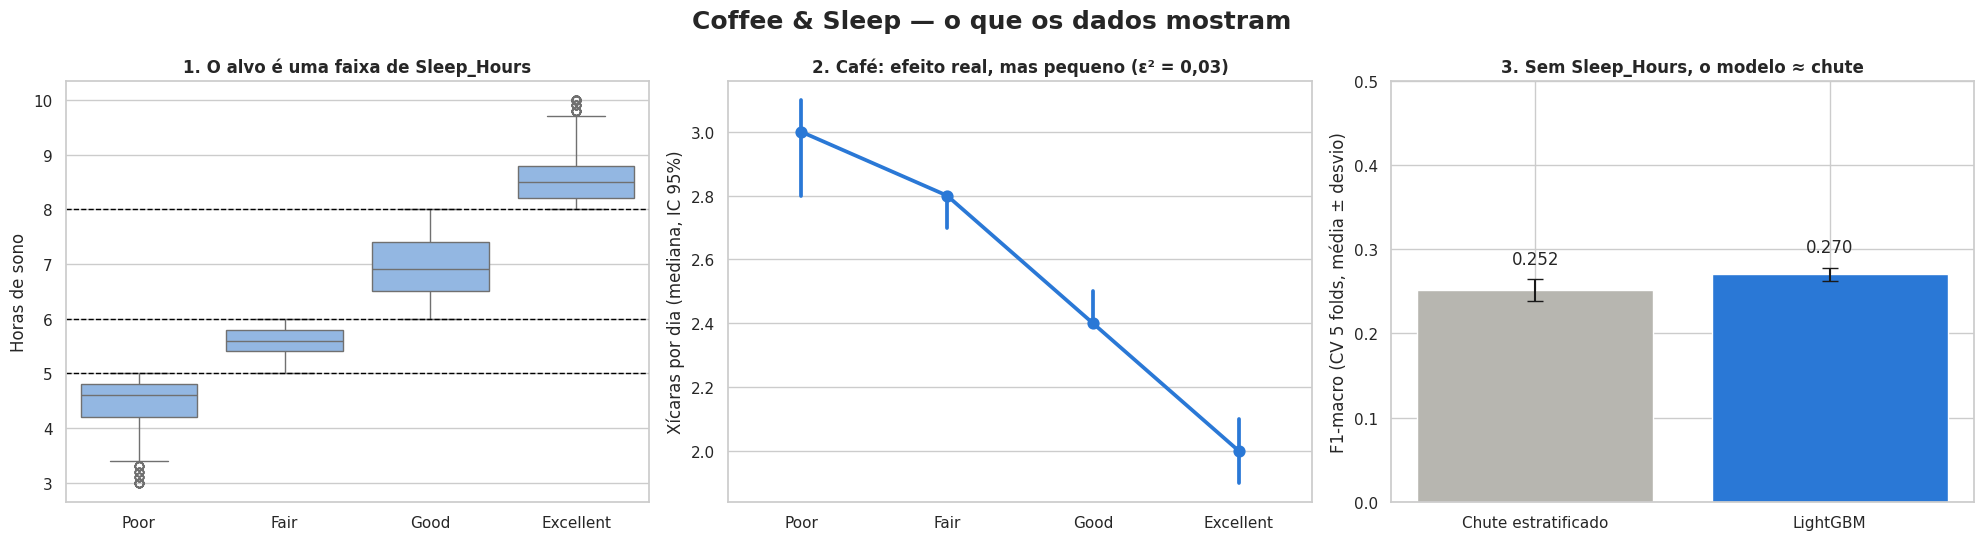

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# 1. A regra
sns.boxplot(data=df, x=ALVO, y="Sleep_Hours", order=CLASSES, color="#86b6ef", ax=axes[0])
for limite in df.groupby(ALVO, observed=True)["Sleep_Hours"].min().iloc[1:]:
    axes[0].axhline(limite, color="black", linestyle="--", linewidth=1)
axes[0].set_title("1. O alvo é uma faixa de Sleep_Hours", fontweight="bold")
axes[0].set_xlabel(""); axes[0].set_ylabel("Horas de sono")

# 2. O único efeito que sobra
sns.pointplot(data=df, x=ALVO, y="Coffee_Intake", order=CLASSES, estimator="median",
              errorbar=("ci", 95), color="#2a78d6", ax=axes[1])
axes[1].set_title("2. Café: efeito real, mas pequeno (ε² = 0,03)", fontweight="bold")
axes[1].set_xlabel(""); axes[1].set_ylabel("Xícaras por dia (mediana, IC 95%)")

# 3. O modelo contra o chute
medias = [f1_base.mean(), resultados[melhor].mean()]
desvios = [f1_base.std(), resultados[melhor].std()]
barras = axes[2].bar(["Chute estratificado", "LightGBM"], medias, yerr=desvios,
                     capsize=6, color=["#b7b6b0", "#2a78d6"])
axes[2].bar_label(barras, labels=[f"{m:.3f}" for m in medias], padding=8)
axes[2].set_ylim(0, 0.5)
axes[2].set_title("3. Sem Sleep_Hours, o modelo ≈ chute", fontweight="bold")
axes[2].set_ylabel("F1-macro (CV 5 folds, média ± desvio)")

fig.suptitle("Coffee & Sleep — o que os dados mostram", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()